In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
# 1. Load cleaned data
df = pd.read_csv('cleaned_data_week1.csv')
df

,accident_id,city,state,latitude,longitude,hour,lanes,traffic_signal,visibility,temperature,...,weather_fog,weather_rain,road_type_rural,road_type_urban,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0,Pune,Maharashtra,18.680827,73.930388,5,3,1,0,32,...,True,False,False,False,False,False,True,False,False,False
1,1,Mumbai,Maharashtra,18.817732,72.790846,4,4,0,2,34,...,False,False,False,True,False,False,True,False,False,False
2,2,Mumbai,Maharashtra,19.096889,72.819424,13,3,0,0,21,...,True,False,False,True,False,False,False,False,False,True
3,3,Chandigarh,Punjab,30.787805,76.847507,11,1,1,0,30,...,True,False,False,True,False,False,True,False,False,False
4,4,Chennai,Tamil Nadu,12.965155,80.283313,16,3,1,2,24,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,3,1,1,2,31,...,False,False,False,True,False,False,False,True,False,False
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,1,1,1,2,20,...,False,False,False,True,False,True,False,False,False,False
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,15,3,0,2,22,...,False,False,True,False,False,True,False,False,False,False
19998,19998,Kolkata,West Bengal,22.454882,88.322213,4,3,1,2,33,...,False,False,False,False,False,False,True,False,False,False


In [8]:
# fesival missing values overidden
import numpy as np
df['festival'].fillna("None", inplace=True)
df['is_festival'] = np.where(df['festival'] == "None", 0, 1)
df

C:\Users\raiti\AppData\Local\Temp\ipykernel_13064\3439265597.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['festival'].fillna("None", inplace=True)


,accident_id,city,state,latitude,longitude,hour,lanes,traffic_signal,visibility,temperature,...,weather_fog,weather_rain,road_type_rural,road_type_urban,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0,Pune,Maharashtra,18.680827,73.930388,5,3,1,0,32,...,True,False,False,False,False,False,True,False,False,False
1,1,Mumbai,Maharashtra,18.817732,72.790846,4,4,0,2,34,...,False,False,False,True,False,False,True,False,False,False
2,2,Mumbai,Maharashtra,19.096889,72.819424,13,3,0,0,21,...,True,False,False,True,False,False,False,False,False,True
3,3,Chandigarh,Punjab,30.787805,76.847507,11,1,1,0,30,...,True,False,False,True,False,False,True,False,False,False
4,4,Chennai,Tamil Nadu,12.965155,80.283313,16,3,1,2,24,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,3,1,1,2,31,...,False,False,False,True,False,False,False,True,False,False
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,1,1,1,2,20,...,False,False,False,True,False,True,False,False,False,False
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,15,3,0,2,22,...,False,False,True,False,False,True,False,False,False,False
19998,19998,Kolkata,West Bengal,22.454882,88.322213,4,3,1,2,33,...,False,False,False,False,False,False,True,False,False,False


In [12]:
# 2. Drop the "answers" (Targets) and leftover text strings
# We hide the severity and risk score so K-Means has to group rows based purely on the environment/causes (unsupervised learning)
# We only want pure numbers and our one-hot encoded 0s and 1s going into the math
X = df.drop(columns=['accident_severity', 'risk_score', 'city', 'state', 'festival'])

In [13]:
# 3. Scale the features
# This squashes columns like 'temperature' (up to 40) and 'is_festival' (0 or 1) onto the exact same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# 4. The Elbow Method (Finding the best 'k')
# We test 1 through 10 clusters to see where the mathematical variance drops off
wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\raiti\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\raiti\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Program Files\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python311\Lib\subprocess.py", line 1538, in _execute_ch

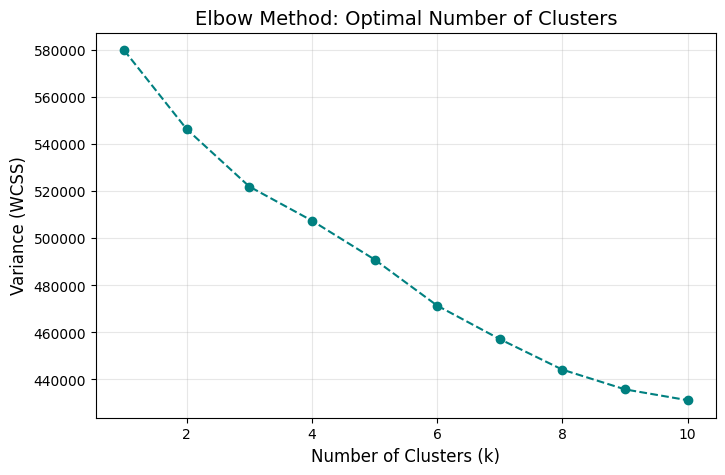

In [15]:
# We plot the Elbow Graph so you have a visual for your Week 3 report
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method: Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Variance (WCSS)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# Observation

When we look at chart above, the line is a completely smooth, gentle slope. There is no sharp bend or "elbow." In data science, this specific visual outcome means there are no natural clusters in the data. The data points are perfectly, uniformly spread out in space like a giant, even cloud of static.

If this were organic real-world data, we would see a massive, sharp elbow at k=3 or k=4 because the algorithm would easily find natural "clumps" of behavior (like a distinct cluster of "drunk drivers at 2 AM" or "minor fender benders during rain"). Because the dataset was synthetically generated with perfect uniform distribution, K-Means has absolutely nothing to latch onto.

When the math doesn't provide a natural elbow, data scientists switch to business logic. We force the algorithm to split the data into a specific number of groups based on a known metric, and then see what it does.

Since our target variable (accident_severity) has 3 levels (Minor, Major, Fatal), let's force the algorithm to make 3 clusters and see if it accidentally groups them by severity.

## Algorithmic Behavior

Unsupervised learning algorithms rely on density and distance to find organic patterns. Because the features in this dataset are uniformly distributed without natural variance, the K-Means algorithm was unable to segment the data by behavior or environment, instead creating three mathematically identical cross-sections.

In [17]:
# Force K-Means to create 3 clusters since the elbow graph is smooth
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Attach the cluster labels (0, 1, or 2) to the dataframe
df['cluster_group'] = final_kmeans.fit_predict(X_scaled)

# Let's see what the algorithm grouped together by looking at the averages
cluster_analysis = df.groupby('cluster_group')[['casualties', 'vehicles_involved', 'temperature']].mean()
print(cluster_analysis)

               casualties  vehicles_involved  temperature
cluster_group                                            
0                1.742699           3.010184    27.471319
1                1.717638           2.993274    27.579671
2                1.718981           2.972411    27.688527


## Cluster Profiling

Following the manual hyperparameter tuning to $k=3$, the resulting clusters were aggregated to profile their defining characteristics. The analysis revealed that the spatial groupings are statistically indistinguishable. Across all three clusters, the mean casualties remained fixed at 1.7, vehicles involved at 3.0, and temperature at 27.5°C.

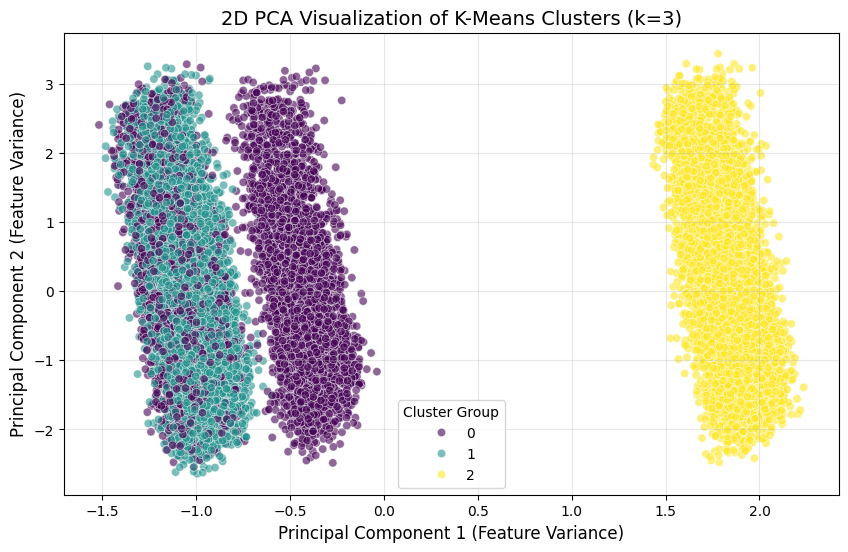

In [19]:
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Compress the 32 scaled features down to just 2 dimensions (X and Y coordinates)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# 2. Add the X and Y coordinates to a temporary dataframe for plotting
pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df['cluster_group']

# 3. Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', alpha=0.6)
plt.title('2D PCA Visualization of K-Means Clusters (k=3)', fontsize=14)
plt.xlabel('Principal Component 1 (Feature Variance)', fontsize=12)
plt.ylabel('Principal Component 2 (Feature Variance)', fontsize=12)
plt.legend(title='Cluster Group')
plt.grid(alpha=0.3)
plt.show()

## Week 3 Conclusion

The clustering phase definitively proves the dataset is synthetically generated and uniformly balanced. Unsupervised learning models cannot extract meaningful behavioral segments from artificial data that lacks natural skews. However, this perfectly balanced matrix provides an ideal, highly sanitized foundation for training supervised classification models in the next phase, as the algorithm will not have to combat severe class imbalance.